<h1>ZCR ANALYSIS</h1>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df=pd.read_csv("zcr.csv")

In [6]:
df.head()

,Current_Node,Alive_node_count,Residual_energy
0,1,100,1.999770
1,1,100,1.999578
2,1,100,1.999679
3,1,100,1.999694
4,1,100,1.999696


In [12]:
df=df.rename(columns={"Current_Node":"Round"})

<h1>Sanity Checks: Removing of immposible values or cleaning data</h1>
<ul>Following maybe the reason for immpossible values
<li>Simulation Rounding</li>
<li>Model Imperfection</li></ul>

In [14]:
#Sanity Checks
df.loc[df["Residual_energy"]<0, "Residual_energy"]=0
df["Alive_node_count"]=df["Alive_node_count"].cummin()

# Lifetime Metrics (ZCR Protocol)

<ul>
<li>N0 represents the initial number of alive nodes at the start of the simulation.</li>
<li>First Node Death (FND) is the round when the first sensor node dies.</li>
<li>Half Node Death (HND) is the round when 50% of the nodes have died.</li>
<li>Last Node Death (LND) is the round when almost all nodes have died.</li>
<li>These metrics describe the stability, degradation, and total lifetime of the ZCR network.</li>
</ul>

In [16]:
#Lifetime Metrics
N0 = df["Alive_node_count"].iloc[0]

FND = df[df["Alive_node_count"] < N0]["Round"].iloc[0]
HND = df[df["Alive_node_count"] <= N0 * 0.5]["Round"].iloc[0]
LND = df[df["Alive_node_count"] <= 1]["Round"].iloc[0]


In [18]:
print("ZCR Lifetime Metrics")
print("FND:", FND)
print("HND:", HND)
print("LND:", LND)

ZCR Lifetime Metrics
FND: 710
HND: 1623
LND: 2944


# Energy Normalization (ZCR Protocol)

<ul>
<li>Energy normalization converts residual energy into percentage form.</li>
<li>The initial total energy of the ZCR network is taken as the reference value.</li>
<li>Each residual energy value is divided by the initial energy.</li>
<li>This scales energy values between 0 and 1.</li>
<li>This allows fair comparison of energy decay behavior.</li>
</ul>

In [20]:
#Energy Normalization
initial_energy=df["Residual_energy"].iloc[0]
df["Norm_Energy"]=df["Residual_energy"]/initial_energy

# Energy Efficiency (ZCR Protocol)

<ul>
<li>Energy efficiency measures the average remaining energy per alive node.</li>
<li>It is calculated by dividing total residual energy by the number of alive nodes.</li>
<li>If no nodes are alive, the value is set to NaN to avoid division errors.</li>
<li>This metric shows how efficiently energy is utilized in the network.</li>
<li>Higher and stable values indicate better energy balancing.</li>
</ul>

In [22]:
#Energy Efficiency
df["Energy_per_Node"]=np.where(
    df["Alive_node_count"]>0,
    df["Residual_energy"]/df["Alive_node_count"],
    np.nan
)

<h1>VISUALIZATION</h1>

In [25]:
step=max(len(df)//3000,1)

# ZCR: Alive Nodes vs Round

<ul>
<li>This graph shows how the number of alive nodes changes over simulation rounds.</li>
<li>The x-axis represents the round number.</li>
<li>The y-axis represents the number of alive nodes.</li>
<li>A slower decline indicates better network stability.</li>
<li>This graph helps identify FND, HND, and LND visually.</li>
</ul>

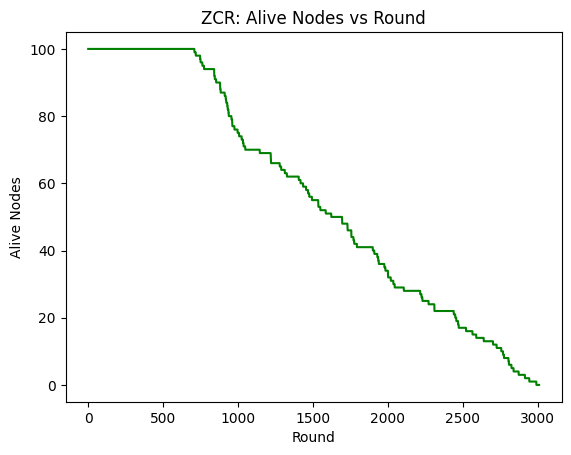

In [35]:
plt.figure()
plt.plot(df["Round"][::step], df["Alive_node_count"][::step],color="green")
plt.xlabel("Round")
plt.ylabel("Alive Nodes")
plt.title("ZCR: Alive Nodes vs Round")
plt.show()


# ZCR: Energy Decay

<ul>
<li>This graph shows how the total energy of the network decreases over time.</li>
<li>The x-axis represents simulation rounds.</li>
<li>The y-axis represents normalized residual energy (between 0 and 1).</li>
<li>A slower and smoother decline indicates better energy management.</li>
<li>This helps evaluate the overall energy performance of the ZCR protocol.</li>
</ul>

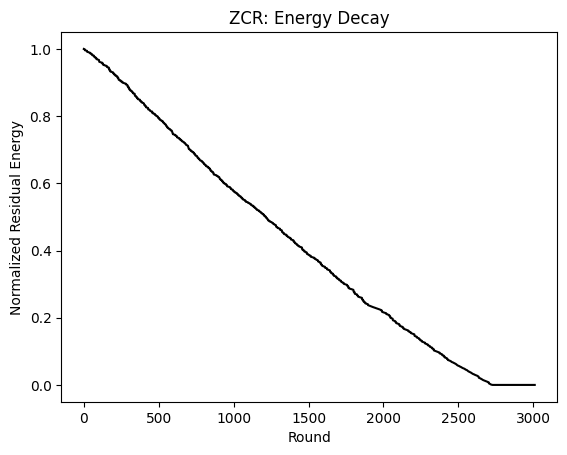

In [37]:
plt.figure()
plt.plot(df["Round"][::step], df["Norm_Energy"][::step],color="black")
plt.xlabel("Round")
plt.ylabel("Normalized Residual Energy")
plt.title("ZCR: Energy Decay")
plt.show()

# ZCR: Energy Efficiency

<ul>
<li>This graph shows the average remaining energy per alive node.</li>
<li>The x-axis represents simulation rounds.</li>
<li>The y-axis represents energy per active node.</li>
<li>A smooth and stable curve indicates balanced energy consumption.</li>
<li>Sharp drops may indicate uneven energy usage or node overloading.</li>
</ul>

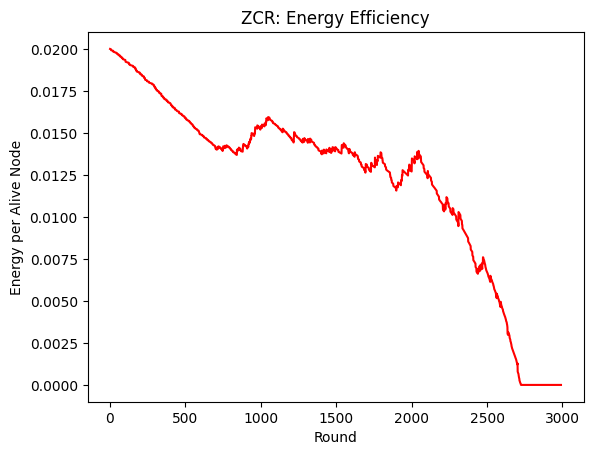

In [39]:
plt.figure()
plt.plot(df["Round"][::step], df["Energy_per_Node"][::step],color="red")
plt.xlabel("Round")
plt.ylabel("Energy per Alive Node")
plt.title("ZCR: Energy Efficiency")
plt.show()